## 1. Imports

In [22]:
import sys
sys.path.insert(0, "scripts")

import os
import re
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm
import torch

from data_prep import load_ml100k, load_ml1m, subset_data, train_test_split, GENRE_COLS
from kg_builder import build_adj, load_or_build_kg, BASE_RELS
from paths import sample_guided_paths, path_is_faithful
from model import (
    build_vocab, is_relation, create_path_dataset, create_model,
    train_model, constrained_generate, extract_patterns, score_path,
    generate_topk, PATTERN_PRIORITY,
)
from metrics import (
    evaluate_ranking, build_user_gender_map, compute_group_metrics,
    compute_all_ilap_metrics, print_ilap_report,
    disparate_impact, equalized_opportunity, demographic_parity,
    counterfactual_fairness_score, print_additional_fairness_report,
    print_path_fairness_report,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cpu


## 2. Data Loading & Preprocessing

In [23]:
# Using MovieLens 1M dataset
MAX_USERS = 500        
MAX_MOVIES = 500       
LIKE_THRESHOLD = 4

# Load ML-1M dataset
ratings, movies, users = load_ml1m("ml-1m")

ratings_sub, movies_sub, users_sub, positive_interactions, user_info = subset_data(
    ratings, movies, users,
    max_users=MAX_USERS,
    max_movies=MAX_MOVIES,
    like_threshold=LIKE_THRESHOLD,
    balance_gender=False
)


Loaded ML-1M -> Ratings: (1000209, 4), Movies: (3883, 21), Users: (6040, 5)
Gender distribution: {'M': 4331, 'F': 1709}
Subset -> Users: 500, Movies: 500, Positive interactions: 91117
Gender split: {'M': 394, 'F': 106}


## 3. Knowledge Graph Construction (Wikidata Cache)

In [24]:
# Use ML-1M specific cache to avoid conflicts with ML-100K cache
KG_CACHE_PATH = "kg_cache_ml1m.pkl"

# Load from cache if exists, otherwise build from scratch using Wikidata
# This will automatically fetch from Wikidata if cache doesn't exist
print(f"Loading/Building Knowledge Graph...")
qid_map, label_cache, kg_triples, readable_triples, movies_sub = load_or_build_kg(
    movies_sub, 
    cache_path=KG_CACHE_PATH
)

print(f"\n{'='*80}")
print("Knowledge Graph Statistics")
print(f"{'='*80}")
print(f"  Movies with KG data: {len(movies_sub)}")
print(f"  KG triples (QID format): {len(kg_triples)}")
print(f"  Readable triples: {len(readable_triples)}")

# Show relation distribution
rel_counts = Counter(r for _, r, _ in readable_triples)
print(f"\nTop 10 relations:")
for rel, cnt in rel_counts.most_common(10):
    print(f"  {rel:20s}: {cnt:5d}")
print(f"{'='*80}")


Loading/Building Knowledge Graph...
Loading KG from cache: kg_cache_ml1m.pkl
  movies with QID: 377, readable_triples: 10372

Knowledge Graph Statistics
  Movies with KG data: 377
  KG triples (QID format): 9995
  Readable triples: 10372

Top 10 relations:
  hasCast             :  6637
  hasGenre            :  1575
  writtenBy           :   656
  country             :   382
  directedBy          :   377
  year                :   377
  hasComposer         :   368


## 4. Train / Test Split

In [25]:
train_interactions, test_interactions, user_item_edges, test_set_dict = train_test_split(
    positive_interactions, movies_sub, test_ratio=0.2
)

Total: 68904
Train: 54923 (79.7%)
Test:  13981 (20.3%)
Avg test items per user: 28.0

Train edges: 54923
Test users:  500
Test pairs:  13981


## 5. Build Adjacency Graph

In [26]:
adj = build_adj(readable_triples, user_item_edges, user_info)
movie_titles_set = set(movies_sub["title"])
print(f"Movie titles in KG: {len(movie_titles_set)}")


Adj → nodes: 5764, total edge-instances: 129076
  rev_hasCast: 4032
  likes: 500
  hasGender: 500
  rev_writtenBy: 434
  rev_likes: 377
  year: 377
  hasGenre: 329
  country: 324
  directedBy: 307
  hasCast: 306
  writtenBy: 305
  hasComposer: 267
  rev_directedBy: 235
  rev_hasComposer: 187
  rev_hasGenre: 157
  rev_year: 59
  rev_country: 16
  rev_hasGender: 2
Movie titles in KG: 377


## 6. Guided Path Sampling


In [27]:
all_users = sorted({u for u, r, t in user_item_edges if r == "likes"})
print(f"Training users: {len(all_users)}")

paths = sample_guided_paths(
    users=all_users,
    adj=adj,
    paths_per_user=150,
    pattern_weights={
        "genre": 0.25, "director": 0.20, "cf": 0.20,
        "cast": 0.15, "composer": 0.10, "writer": 0.10,
    },
)

faithful = sum(path_is_faithful(p, adj) for p in paths) / len(paths)
print(f"Faithful paths: {faithful:.1%}")

print("\nSample paths:")
for p in paths[:3]:
    print("  ", " -> ".join(str(x) for x in p))


Training users: 500
Pattern distribution:
  genre: 35113 (46.8%)
  director: 10365 (13.8%)
  cf: 18927 (25.2%)
  cast: 4605 (6.1%)
  composer: 3272 (4.4%)
  writer: 2718 (3.6%)
Total paths before dedupe: 75000
After dedupe: 73193
Faithful paths: 100.0%

Sample paths:
   User_1004 -> likes -> Conan the Barbarian (1982) -> hasGenre -> film based on literature -> rev_hasGenre -> Rear Window (1954)
   User_1004 -> likes -> Young Frankenstein (1974) -> rev_likes -> User_1019 -> likes -> Terms of Endearment (1983)
   User_1004 -> likes -> Predator (1987) -> hasGenre -> thriller film -> rev_hasGenre -> Face/Off (1997)


## 7. Build Vocabulary & Dataset

In [28]:
vocab, id2tok, PAD, BOS, EOS, UNK = build_vocab(paths, BASE_RELS)
print(f"Vocab size: {len(vocab)}")

train_loader, val_loader, MAX_LEN, all_entities = create_path_dataset(
    paths, vocab, BASE_RELS, PAD, BOS, EOS, UNK,
    batch_size=64, val_ratio=0.1,
)


Vocab size: 2074
MAX_LEN: 9
Train paths: 65873, Val paths: 7320
Train batches: 1030, Val batches: 115


## 8. Create & Train GPT-2 Path Model

In [ ]:
model = create_model(
    vocab_size=len(vocab), max_len=MAX_LEN,
    BOS=BOS, EOS=EOS, device=device,
    n_embd=192, n_layer=4, n_head=4, dropout=0.1,
)

model = train_model(
    model, train_loader, val_loader, device=device,
    epochs=10, lr=3e-4, patience=2,
)


Model params: 2,179,776


Epoch 1/10: 100%|██████████| 1030/1030 [03:27<00:00,  4.96it/s, loss=2.9043, lr=2.93e-04]


  Epoch 1 val_loss: 2.7250


Epoch 2/10:  14%|█▍        | 145/1030 [00:31<03:17,  4.49it/s, loss=2.7056, lr=2.91e-04]

## 9. Sample Recommendation

In [ ]:
sample_user = list(test_set_dict.keys())[0]
topk = generate_topk(
    sample_user, model, vocab, id2tok, adj, BASE_RELS,
    movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
    device=device, K=5,
)

print(f"Recommendations for {sample_user}:")
for movie, pat_type in topk:
    print(f"  [{pat_type:>10}]  {movie}")


Recommendations for User_48:
  [  director]  Sixteen Candles (1984)
  [  director]  Indiana Jones and the Temple of Doom (1984)
  [     genre]  Boys Don't Cry (1999)
  [    writer]  Mr. Mom (1983)
  [     genre]  Chicken Run (2000)


## 10. Evaluate on All Test Users

In [ ]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)
results = []

print(f"Evaluating on {len(test_set_dict)} users...")
for user_node, ground_truths in tqdm(test_set_dict.items(), desc="Evaluating"):
    if user_node not in adj:
        continue
    topk_with_type = generate_topk(
        user_node, model, vocab, id2tok, adj, BASE_RELS,
        movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
        device=device, K=MAX_K,
    )
    ranked_list = [c for c, t in topk_with_type]
    pattern_types = [t for c, t in topk_with_type]
    results.append({
        "user": user_node,
        "ground_truths": ground_truths,
        "top_k_recs": ranked_list,
        "pattern_types": pattern_types,
        "num_gt": len(ground_truths),
    })

print(f"Evaluated {len(results)} users")


Evaluating on 500 users...


Evaluating: 100%|██████████| 500/500 [14:38<00:00,  1.76s/it]

Evaluated 500 users


## 11. Ranking Metrics (HR, MRR, NDCG)

In [ ]:
ranking_metrics = evaluate_ranking(results, k_values=K_VALUES)

print(f"{'K':>4} | {'HR@K':>8} | {'MRR@K':>8} | {'NDCG@K':>8}")
print("-" * 40)
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"{k:>4} | {m['HR']:>8.4f} | {m['MRR']:>8.4f} | {m['NDCG']:>8.4f}")


   K |     HR@K |    MRR@K |   NDCG@K
----------------------------------------
   1 |   0.1540 |   0.1540 |   0.1540
   3 |   0.3900 |   0.2540 |   0.1581
   5 |   0.5160 |   0.2825 |   0.1514
  10 |   0.7020 |   0.3072 |   0.1394


## 12. Ranking Metrics Visualization

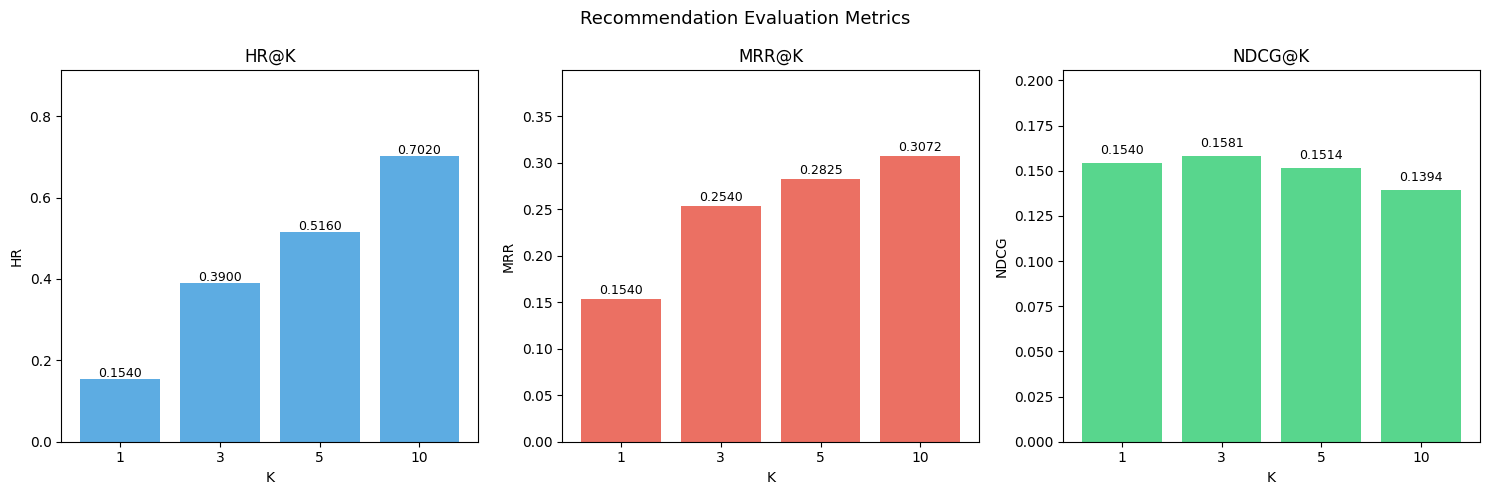

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ["HR", "MRR", "NDCG"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, name, color in zip(axes, metric_names, colors):
    values = [ranking_metrics[k][name] for k in K_VALUES]
    ax.bar([str(k) for k in K_VALUES], values, color=color, alpha=0.8)
    ax.set_title(f"{name}@K")
    ax.set_xlabel("K")
    ax.set_ylabel(name)
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1.0)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Recommendation Evaluation Metrics", fontsize=13)
plt.tight_layout()
plt.show()


## 13. Extended Metrics (Coverage, Diversity, Novelty)

In [ ]:
# Coverage
all_recommended = set()
for res in results:
    all_recommended.update(res["top_k_recs"][:MAX_K])
coverage = len(all_recommended) / len(movie_titles_set)
print(f"Coverage@{MAX_K}: {coverage:.4f} ({len(all_recommended)}/{len(movie_titles_set)} unique movies)")

def intra_list_diversity(ranked_list):
    if len(ranked_list) < 2:
        return 0.0
    genre_sets = []
    for movie in ranked_list:
        genres = adj.get(movie, {}).get("hasGenre", set())
        genre_sets.append(genres)
    distances = []
    for i in range(len(genre_sets)):
        for j in range(i + 1, len(genre_sets)):
            union = genre_sets[i] | genre_sets[j]
            inter = genre_sets[i] & genre_sets[j]
            distances.append(1.0 - len(inter) / len(union) if union else 1.0)
    return np.mean(distances) if distances else 0.0

diversities = [intra_list_diversity(res["top_k_recs"][:MAX_K]) for res in results]
avg_diversity = np.mean(diversities)
print(f"Avg Intra-List Diversity@{MAX_K}: {avg_diversity:.4f}")

# Novelty
item_popularity = {}
for movie in movie_titles_set:
    item_popularity[movie] = len(adj.get(movie, {}).get("rev_likes", set()))
max_popularity = max(item_popularity.values()) if item_popularity else 1

def novelty_score(ranked_list):
    if not ranked_list:
        return 0.0
    return np.mean([1.0 - item_popularity.get(m, 0) / max(max_popularity, 1) for m in ranked_list])

novelties = [novelty_score(res["top_k_recs"][:MAX_K]) for res in results]
avg_novelty = np.mean(novelties)
print(f"Avg Novelty@{MAX_K}: {avg_novelty:.4f}")

# Pattern distribution
pattern_counter = Counter()
for res in results:
    for pt in res.get("pattern_types", []):
        pattern_counter[pt] += 1
total_pats = sum(pattern_counter.values())
print(f"\nRecommendation Pattern Distribution:")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")


Coverage@10: 0.8037 (303/377 unique movies)
Avg Intra-List Diversity@10: 0.9029
Avg Novelty@10: 0.6695

Recommendation Pattern Distribution:
  genre: 1947 (38.9%)
  director: 1584 (31.7%)
  composer: 585 (11.7%)
  cast: 523 (10.5%)
  writer: 361 (7.2%)


## 14. Fairness Metrics: Per-Gender Breakdown

In [ ]:
user_gender_map = build_user_gender_map(users_sub)
n_m = sum(1 for g in user_gender_map.values() if g == "M")
n_f = sum(1 for g in user_gender_map.values() if g == "F")
print(f"Gender map: {n_m} Male, {n_f} Female users")

group_metrics = compute_group_metrics(results, user_gender_map, K_VALUES)

print(f"\n{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
print("-" * 65)
for k in K_VALUES:
    gm = group_metrics["M"][k]
    gf = group_metrics["F"][k]
    print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
          f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
          f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")


Gender map: 394 Male, 106 Female users

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
-----------------------------------------------------------------
   1 |  0.1599 |  0.1321 |  0.1599 |  0.1321 |   0.1599 |   0.1321
   3 |  0.3934 |  0.3774 |  0.2585 |  0.2374 |   0.1567 |   0.1632
   5 |  0.5203 |  0.5000 |  0.2873 |  0.2648 |   0.1508 |   0.1533
  10 |  0.7005 |  0.7075 |  0.3110 |  0.2931 |   0.1391 |   0.1404


## 15. ILAP Fairness Metrics

In [ ]:
ilap = compute_all_ilap_metrics(results, user_gender_map, k=10, disadv="F", adv="M")
print_ilap_report(ilap, k=10, label="GPT-2 Path Model")



──────────────────────────────────────────────────
ILAP Fairness Metrics — GPT-2 Path Model @ K=10
──────────────────────────────────────────────────
  Differential Fairness ε               2.8920  (lower = fairer)
  Value Unfairness                      0.2124  (≈0 = fair)
  Absolute Unfairness                   0.1842  (≈0 = fair)
  Underestimation Unfairness            0.1733  (≈0 = fair)
  Overestimation Unfairness             0.0391  (≈0 = fair)
  NonParity Unfairness                  0.0203  (≈0 = fair)
  KS Statistic                          0.0341  (p=1.000)
  Generalized Cross Entropy            -0.1869  (lower = fairer)


## 16. Additional Fairness Metrics

In [ ]:
print_additional_fairness_report(
    results, group_metrics, user_gender_map, adj,
    k_values=(5, 10), label="GPT-2 Path Model",
)



──────────────────────────────────────────────────
Additional Fairness Metrics — GPT-2 Path Model
──────────────────────────────────────────────────
    K |     ΔHR |    ΔMRR |    ΔNDCG |       DI |    EqOpp |       DP |       CF
  ------------------------------------------------------------------------
    5 |  0.0203 |  0.0225 |   0.0025 |   0.9610 |   0.0203 |   0.6654 |   0.0648
        DI PASS (≥0.8 required)
   10 |  0.0070 |  0.0179 |   0.0013 |   0.9901 |   0.0070 |   0.8284 |   0.0756
        DI PASS (≥0.8 required)


## 18. Comprehensive Report

In [ ]:
K_R = 10
cf_score, _ = counterfactual_fairness_score(results, user_gender_map, adj, K_R)
di = disparate_impact(group_metrics, K_R)
eo = equalized_opportunity(group_metrics, K_R)
dp = demographic_parity(results, user_gender_map, K_R)

print("=" * 60)
print("GPT-2 PATH MODEL - COMPREHENSIVE REPORT")
print(f"ML-100K | {MAX_USERS} users, {MAX_MOVIES} movies | K={K_R}")
print("=" * 60)

print("\n-- Accuracy --")
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"  HR@{k}={m['HR']:.4f}  MRR@{k}={m['MRR']:.4f}  NDCG@{k}={m['NDCG']:.4f}")

print(f"\n-- Extended --")
print(f"  Coverage@{MAX_K}:  {coverage:.4f}")
print(f"  Diversity@{MAX_K}: {avg_diversity:.4f}")
print(f"  Novelty@{MAX_K}:   {avg_novelty:.4f}")

print("\n-- ILAP Fairness --")
for key, val in ilap.items():
    if key != "KS_pval":
        print(f"  {key:<8} {val:.4f}")

print("\n-- Additional Fairness --")
print(f"  Disparate Impact@{K_R}:        {di:.4f}")
print(f"  Equalized Opportunity@{K_R}:   {eo:.4f}")
print(f"  Demographic Parity@{K_R}:      {dp:.4f}")
print(f"  Counterfactual Fairness@{K_R}: {cf_score:.4f}")

print("\n-- Pattern Distribution --")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")

print("=" * 60)

GPT-2 PATH MODEL - COMPREHENSIVE REPORT
ML-100K | 500 users, 500 movies | K=10

-- Accuracy --
  HR@1=0.1540  MRR@1=0.1540  NDCG@1=0.1540
  HR@3=0.3900  MRR@3=0.2540  NDCG@3=0.1581
  HR@5=0.5160  MRR@5=0.2825  NDCG@5=0.1514
  HR@10=0.7020  MRR@10=0.3072  NDCG@10=0.1394

-- Extended --
  Coverage@10:  0.8037
  Diversity@10: 0.9029
  Novelty@10:   0.6695

-- ILAP Fairness --
  DF       2.8920
  VU       0.2124
  AU       0.1842
  UU       0.1733
  OU       0.0391
  NU       0.0203
  KS       0.0341
  GCE      -0.1869

-- Additional Fairness --
  Disparate Impact@10:        0.9901
  Equalized Opportunity@10:   0.0070
  Demographic Parity@10:      0.8284
  Counterfactual Fairness@10: 0.0756

-- Pattern Distribution --
  genre: 1947 (38.9%)
  director: 1584 (31.7%)
  composer: 585 (11.7%)
  cast: 523 (10.5%)
  writer: 361 (7.2%)


## Baselines

In [ ]:
import importlib
import scripts.baselines as baselines
importlib.reload(baselines)


### Random Baseline

In [ ]:
results_random = baselines.run_random(
    test_set_dict, list(movie_titles_set), k_values=K_VALUES
)
group_metrics_random = baselines.compute_group_metrics(
    results_random, user_gender_map, K_VALUES
)

### Popularity Baseline

In [ ]:
results_popularity = baselines.run_popularity(
    test_set_dict, user_item_edges, list(movie_titles_set), k_values=K_VALUES
)
group_metrics_popularity = baselines.compute_group_metrics(
    results_popularity, user_gender_map, K_VALUES
)

### GPT-2 + Gender Baseline

In [ ]:
results_gender, model_gender, *_gender_artifacts = baselines.run_gpt2_gender(
    test_set_dict, adj, all_users, movie_titles_set,
    BASE_RELS, device, k_values=K_VALUES
)
group_metrics_gender = baselines.compute_group_metrics(
    results_gender, user_gender_map, K_VALUES
)

## Visualizations — All Models Comparison

In [ ]:
import importlib
import scripts.visualizations as viz
importlib.reload(viz)

from metrics import evaluate_ranking
ranking_metrics_random     = evaluate_ranking(results_random,     k_values=K_VALUES)
ranking_metrics_popularity = evaluate_ranking(results_popularity, k_values=K_VALUES)
ranking_metrics_gender     = evaluate_ranking(results_gender,     k_values=K_VALUES)


In [ ]:
models = {
    "GPT-2 ": (results,           ranking_metrics,            group_metrics),
    "Random":       (results_random,     ranking_metrics_random,     group_metrics_random),
    "Popularity":   (results_popularity, ranking_metrics_popularity, group_metrics_popularity),
    "GPT-2+Gender": (results_gender,     ranking_metrics_gender,     group_metrics_gender),
}

viz.plot_all(models, k_values=K_VALUES, save_dir="figures")